In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%pip install bidict
from bidict import bidict
import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix

In [3]:
ENCODER = bidict({
    'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6,
    'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12,
    'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18,
    'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24,
    'Y': 25, 'Z': 26
})

In [6]:
# labels = np.load('/data/labels.npy')
labels = np.load('labels.npy')
labels = np.array([ENCODER[x] for x in labels])
labels.shape

(1300,)

In [7]:
labels

array([ 2,  1,  3, ..., 24, 25, 26])

In [8]:
# imgs = np.load('/data/images.npy')
imgs = np.load('images.npy')
imgs = imgs.astype("float32") / 255
imgs.shape

(1300, 50, 50)

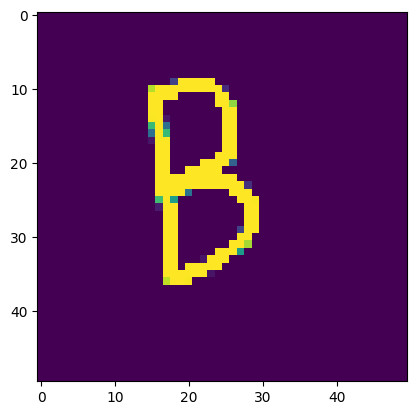

In [9]:
plt.figure()
plt.imshow(imgs[0])
plt.grid(False)
plt.show()

In [10]:
imgs = np.expand_dims(imgs, -1)

In [11]:
labels, imgs = shuffle(labels, imgs)
split = .75

labels_train = labels[:int(len(labels) * split)]
labels_test = labels[int(len(labels) * split):]

imgs_train = imgs[:int(len(imgs) * split)]
imgs_test = imgs[int(len(imgs) * split):]

In [12]:
batch_size = 16
epochs = 20

model = keras.Sequential([
    keras.Input(shape=(50, 50, 1)),
    layers.Conv2D(256, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.3),
    layers.Conv2D(512, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.3),
    layers.Conv2D(1024, kernel_size=5, activation='relu'),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(len(ENCODER)+1, activation='softmax')
])

In [13]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2)
optimizer = keras.optimizers.Adam()

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

In [14]:
model.fit(imgs_train,
          labels_train,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(imgs_test, labels_test),
          callbacks=[early_stopping])

Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 226ms/step - accuracy: 0.0903 - loss: 3.1656 - val_accuracy: 0.2954 - val_loss: 2.4769
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4954 - loss: 1.7268 - val_accuracy: 0.5538 - val_loss: 1.5139
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6913 - loss: 1.0205 - val_accuracy: 0.6338 - val_loss: 1.1852
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7754 - loss: 0.7115 - val_accuracy: 0.7077 - val_loss: 1.0221
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8215 - loss: 0.5400 - val_accuracy: 0.7108 - val_loss: 1.0224
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8574 - loss: 0.4201 - val_accuracy: 0.7354 - val_loss: 0.9806
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8769 - loss: 0.3498 - val_accuracy: 0.7754 - val_loss: 0.9023
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9149 - loss: 0.2681 - val_accuracy: 0.7877 -

In [15]:
labels_pred = np.argmax(model.predict(imgs_test), axis=-1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step


In [16]:
cm = confusion_matrix(labels_test, labels_pred, labels=list(ENCODER.inverse.keys()))

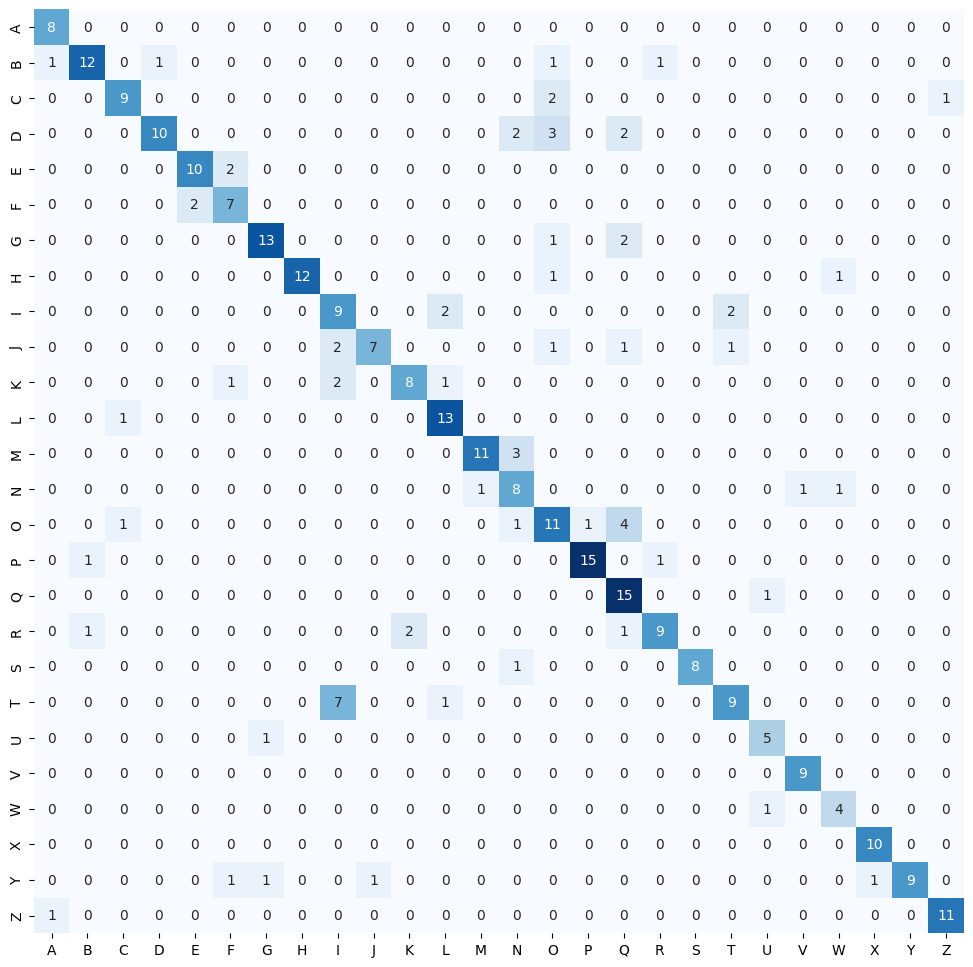

In [17]:
plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=True, cbar=False, cmap="Blues", xticklabels=list(ENCODER.keys()), yticklabels=list(ENCODER.keys()))
plt.show()

In [19]:
model.save('../letter.keras')

In [20]:
model.save('../letter.h5')